In [43]:
!wget https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt

--2026-09-29 11:27:32--  https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1115394 (1.1M) [text/plain]
Saving to: ‘input.txt.2’

input.txt.2         100%[===================>]   1.06M  --.-KB/s    in 0.01s   

2026-09-29 11:27:33 (104 MB/s) - ‘input.txt.2’ saved [1115394/1115394]



In [44]:
import sentencepiece as spm
import io

with open("input.txt") as f:
  text = f.read()

vocab_size = 1000

spm.SentencePieceTrainer.train(
    input="input.txt",
    model_prefix="m",
    vocab_size=vocab_size,
    user_defined_symbols=["<br>"]
)
sp = spm.SentencePieceProcessor(model_file='m.model')

# stoi = {s: i for i,s in enumerate(vocab)}
# itos = {i: s for i,s in enumerate(vocab)}

# def encode(text):
#   return [stoi[c] for c in list(text)]

# def decode(ids):
#   return "".join([itos[t] for t in ids])

def encode(text):
  return sp.encode(text.replace("\n", "<br>"))

def decode(ids):
  return sp.decode(ids).replace("<br>", "\n")

In [45]:
import math
from typing import Literal

import torch
import torch.nn as nn
from torch.nn import functional as F

class TokenEmbedding(nn.Module):
    def __init__(self, vocab_size, d_model):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, d_model)
        self.scale = math.sqrt(d_model)

    def forward(self, x):
        return self.embedding(x) * self.scale


class PositionEmbedding(nn.Module):
    def __init__(self, max_seq_len, d_model):
        super().__init__()

        self.max_seq_len = max_seq_len

        position_encoding = torch.empty(max_seq_len, d_model)

        for pos in range(max_seq_len):
            for i in range(d_model // 2):
                angle = pos / math.pow(10000, (2 * i) / d_model)
                position_encoding[pos, 2 * i] = math.sin(angle)
                position_encoding[pos, 2 * i + 1] = math.cos(angle)

        self.register_buffer("position_encoding", position_encoding)

    def forward(self, x):
        _, seq_len, _ = x.shape

        assert seq_len <= self.max_seq_len

        return x + self.position_encoding[:seq_len]


class Attention(nn.Module):
    def __init__(self, d_model, heads):
        super().__init__()

        assert d_model % heads == 0

        self.heads = heads
        self.head_dim = d_model // heads

        self.query = nn.Linear(d_model, d_model)
        self.key = nn.Linear(d_model, d_model)
        self.value = nn.Linear(d_model, d_model)

        self.softmax = nn.Softmax(dim=-1)
        self.concat = nn.Linear(d_model, d_model)

    def forward(self, query_input, key_value_input, mask=None):
        B, Q_T, d_model = query_input.shape
        _, KV_T, _ = key_value_input.shape

        q = self.query(query_input)
        k = self.key(key_value_input)
        v = self.value(key_value_input)

        q = q.view(B, Q_T, self.heads, self.head_dim)
        k = k.view(B, KV_T, self.heads, self.head_dim)
        v = v.view(B, KV_T, self.heads, self.head_dim)

        q = q.transpose(1, 2)
        k = k.transpose(1, 2)
        v = v.transpose(1, 2)

        wei = q @ k.transpose(-2, -1)
        wei = wei / math.sqrt(self.head_dim)

        if mask is not None:
            wei = wei.masked_fill(mask[:Q_T, :KV_T], float("-inf"))

        wei = self.softmax(wei)

        x = wei @ v
        x = x.transpose(1, 2)
        x = x.reshape(B, Q_T, d_model)

        return self.concat(x)


class FeedForward(nn.Module):
    def __init__(self, d_model, d_ff):
        super().__init__()

        self.linear1 = nn.Linear(d_model, d_ff)
        self.linear2 = nn.Linear(d_ff, d_model)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.linear1(x)
        x = self.relu(x)
        return self.linear2(x)


class EncoderLayer(nn.Module):
    def __init__(self, d_model, heads, d_ff, norm: Literal["pre", "post"] = "post"):
        super().__init__()
        assert(norm == "pre" or norm == "post")

        self.norm = norm

        self.sa = Attention(d_model, heads)
        self.ff = FeedForward(d_model, d_ff)

        self.ln1 = nn.LayerNorm(d_model)
        self.ln2 = nn.LayerNorm(d_model)

    def forward(self, x):
        if self.norm == "post":
          x = self.ln1(x + self.sa(x, x))
          x = self.ln2(x + self.ff(x))
        elif self.norm == "pre":
          x_norm = self.ln1(x)
          x = x + self.sa(x_norm, x_norm)

          x_norm = self.ln2(x)
          x = x + self.ff(x_norm)

        return x


class Encoder(nn.Module):
    def __init__(self, num_layers, d_model, heads, d_ff):
        super().__init__()

        self.layers = nn.ModuleList(
            EncoderLayer(d_model, heads, d_ff)
            for _ in range(num_layers)
        )

    def forward(self, x):
        for layer in self.layers:
            x = layer(x)

        return x


class DecoderLayer(nn.Module):
    def __init__(self, d_model, heads, d_ff, max_seq_len, decoder_only=False):
        super().__init__()

        self.decoder_only = decoder_only

        self.register_buffer(
            "mask",
            torch.tril(torch.ones(max_seq_len, max_seq_len)) == 0,
        )

        self.sa = Attention(d_model, heads)
        self.ln1 = nn.LayerNorm(d_model)

        if not decoder_only:
            self.ca = Attention(d_model, heads)
            self.ln2 = nn.LayerNorm(d_model)

        self.ff = FeedForward(d_model, d_ff)
        self.ln3 = nn.LayerNorm(d_model)

    def forward(self, x, memory=None):
        x = self.ln1(x + self.sa(x, x, self.mask))

        if not self.decoder_only and memory is not None:
            x = self.ln2(x + self.ca(x, memory))

        x = self.ln3(x + self.ff(x))

        return x


class Decoder(nn.Module):
    def __init__(
        self,
        num_layers,
        d_model,
        heads,
        d_ff,
        max_seq_len,
        decoder_only=False,
    ):
        super().__init__()

        self.layers = nn.ModuleList(
            DecoderLayer(
                d_model,
                heads,
                d_ff,
                max_seq_len,
                decoder_only,
            )
            for _ in range(num_layers)
        )

    def forward(self, x, memory=None):
        for layer in self.layers:
            x = layer(x, memory)

        return x


class Transformer(nn.Module):
    def __init__(
        self,
        src_vocab_size,
        tgt_vocab_size,
        d_model,
        max_seq_len,
        num_layers,
        heads,
        d_ff,
        decoder_only=False,
    ):
        super().__init__()

        self.decoder_only = decoder_only

        if not decoder_only:
            self.src_token_embedding = TokenEmbedding(
                src_vocab_size,
                d_model,
            )
            self.encoder = Encoder(
                num_layers,
                d_model,
                heads,
                d_ff,
            )

        self.tgt_token_embedding = TokenEmbedding(
            tgt_vocab_size,
            d_model,
        )
        self.position_embedding = PositionEmbedding(
            max_seq_len,
            d_model,
        )
        self.decoder = Decoder(
            num_layers,
            d_model,
            heads,
            d_ff,
            max_seq_len,
            decoder_only,
        )
        self.output_proj = nn.Linear(d_model, tgt_vocab_size)

    def forward(self, target, source=None):
        assert self.decoder_only is (source is None)

        if not self.decoder_only:
            x = self.src_token_embedding(source)
            x = self.position_embedding(x)
            memory = self.encoder(x)
        else:
            memory = None

        x = self.tgt_token_embedding(target)
        x = self.position_embedding(x)
        x = self.decoder(x, memory)
        x = self.output_proj(x)

        return x

    @torch.no_grad()
    def generate(self, idx, max_new_tokens):
        for _ in range(max_new_tokens):
            idx_cond = idx[:, -block_size:]
            logits = self(idx_cond)
            logits = logits[:, -1, :]
            # logits = logits / temperature

            probs = F.softmax(logits, dim=-1)
            idx_next = torch.multinomial(probs, num_samples=1)
            idx = torch.cat((idx, idx_next), dim=1)
        return idx


batch_size = 2
d_model = 512
heads = 8
d_ff = 2048
num_layers = 6
src_len = 4
tgt_len = 6
max_seq_len = 1024
src_vocab_size = vocab_size
tgt_vocab_size = vocab_size
temperature = 0.7

target = torch.randint(0, vocab_size, (batch_size, tgt_len))

In [46]:
transformer = Transformer(
    src_vocab_size,
    tgt_vocab_size,
    d_model,
    max_seq_len,
    num_layers,
    heads,
    d_ff,
    decoder_only=True,
)

100%|██████████| 500/500 [01:29<00:00,  5.56it/s, train_loss=3.6659, val_loss=3.9530]


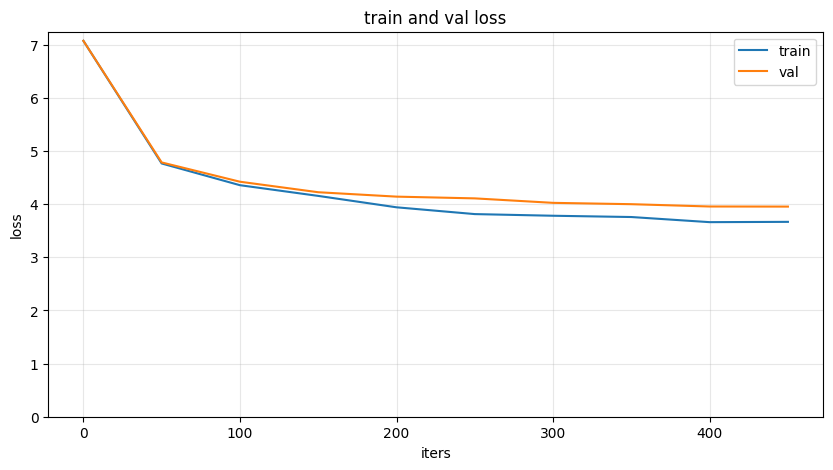

In [47]:
from tqdm import tqdm

data = torch.tensor(encode(text), dtype=torch.long)

block_size = 128
learning_rate = 1e-4
batch_size = 32
max_iters = 500
eval_interval = 50
eval_iters = 20

train_split = 0.9
train_data = data[:round(train_split * len(data))]
val_data = data[round(train_split * len(data)):]

def get_batch(split):
  data = train_data if split == "train" else val_data
  ix = torch.randint(len(data) - block_size, (batch_size, ))
  x = torch.stack([data[i:i+block_size] for i in ix])
  y = torch.stack([data[i+1:i+block_size+1] for i in ix])
  return x, y

device = "cuda" if torch.cuda.is_available() else "cpu"
transformer.to(device)

optimizer = torch.optim.AdamW(transformer.parameters(), lr=learning_rate)

@torch.no_grad()
def estimate_loss():
  out = {}
  transformer.eval()
  losses = torch.zeros(eval_iters)
  for k in range(eval_iters):
    x, y = get_batch("val")
    x, y = x.to(device), y.to(device)

    logits = transformer(x)
    logits = logits.transpose(-2, -1)
    loss = F.cross_entropy(logits, y)
    losses[k] = loss
  out = losses.mean()
  transformer.train()
  return out

import matplotlib
import matplotlib.pyplot as plt

from tqdm import tqdm
import torch.nn.functional as F
import matplotlib.pyplot as plt

train_iters = []
train_losses = []

val_iters = []
val_losses = []

pbar = tqdm(range(max_iters))

for step in pbar:
    if step % eval_interval == 0:
        loss = estimate_loss()

        val_loss = loss["val"] if isinstance(loss, dict) else loss

        val_iters.append(step)
        val_losses.append(val_loss.item())

        pbar.set_postfix(
            train_loss=f"{train_losses[-1]:.4f}" if train_losses else "N/A",
            val_loss=f"{val_loss.item():.4f}"
        )

    x, y = get_batch("train")
    x, y = x.to(device), y.to(device)

    logits = transformer(x)

    logits = logits.transpose(-2, -1)

    loss = F.cross_entropy(logits, y)

    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()

    if step % eval_interval == 0:
      train_iters.append(step)
      train_losses.append(loss.item())

    pbar.set_postfix(
        train_loss=f"{train_losses[-1]:.4f}",
        val_loss=(f"{val_losses[-1]:.4f}")
    )

plt.figure(figsize=(10, 5))

plt.plot(train_iters, train_losses, label="train")
plt.plot(val_iters, val_losses, label="val")

plt.xlabel("iters")
plt.ylabel("loss")
plt.title("train and val loss")

plt.ylim(bottom=0)
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [48]:
t = "ANAND:"
x = torch.tensor([encode(t)], dtype=torch.long).to(device)
y = transformer.generate(x, max_new_tokens=300)
print(decode(y.tolist()[0]).replace("<br>", "\n"))

ANAND:
Ar in vier, songs, for his fear Richmond and which are no others,
Sterdching nature, thee an in the way,
Tho Tybalt here that unrformalous libirs behrizech lives withinationempit work,
And Richard withge with death! talk than a ty thou myself topets mylouth,
The's, and come, sirure and thyise
Sueft were the crid Romeo did res it in-- so,
And that youthileverives, to runenat lightle.
HASTINGBRA signd hope?ED:
h Tard nor garent
Whatiingere sweet fakend strikes slain, and will be indeed.
Wer not?
LAnd post me! what? Come, Have away mother please:
st thou taleanuset had
Foript were in aded cors must abour mad.
HOfes of you be timety husband; you.
 how III:
Proaes, royal c princes slain, give thee, which is wraave;
Aloryrt where
